<a href="https://colab.research.google.com/github/Misha2636/Junior-Data-Scientist-ML-Intern-Python-Machine-Learning-Data-Analysis-/blob/PROJECT-3-Supervised-Learning-Model-Comparison/PROJECT_3_Supervised_Learning_Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Supervised Learning Model Comparison

**Author:** Amisha (“Misha”)  
**Goal:** Compare multiple supervised learning algorithms to evaluate performance tradeoffs across business-relevant metrics.

## Project Objectives
- Prepare and encode structured data
- Train multiple classification models
- Evaluate models using precision, recall, and ROC-AUC
- Identify optimal model selection under different business constraints


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve
)

sns.set(style="whitegrid")

In [2]:
import os
os.listdir("/content")

['.config',
 'WA_Fn-UseC_-Telco-Customer-Churn.csv',
 '.ipynb_checkpoints',
 'sample_data']

In [3]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df = df.dropna()

# Convert target to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Drop ID column
df = df.drop(columns=["customerID"])

# One-hot encode categorical variables
df = pd.get_dummies(df, drop_first=True)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,0,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,0,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,1,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,0,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,1,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:,1]

In [7]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

knn_preds = knn.predict(X_test_scaled)
knn_probs = knn.predict_proba(X_test_scaled)[:,1]

In [8]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]

In [9]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Random Forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, knn_probs),
        roc_auc_score(y_test, rf_probs)
    ]
})

results

,Model,ROC-AUC
0,Logistic Regression,0.802599
1,KNN,0.537205
2,Random Forest,0.827735


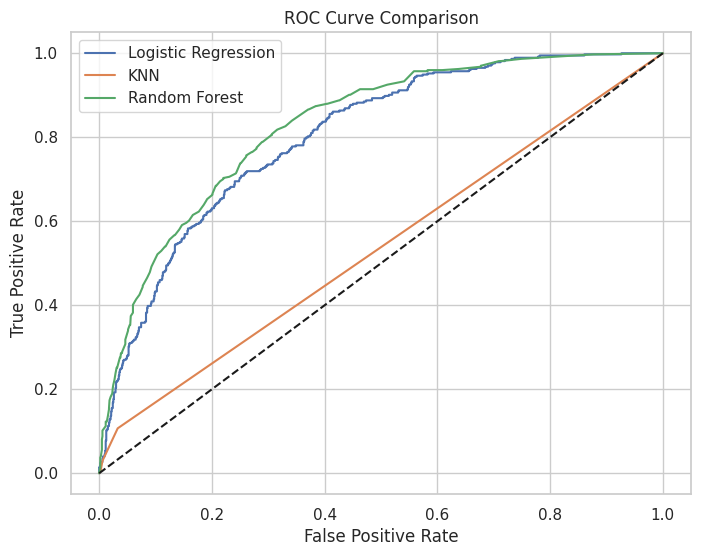

In [10]:
plt.figure(figsize=(8,6))

for model_name, probs in zip(
    ["Logistic Regression", "KNN", "Random Forest"],
    [lr_probs, knn_probs, rf_probs]
):
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=model_name)

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [11]:
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))

print("=== KNN ===")
print(classification_report(y_test, knn_preds))

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.59      0.50      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

=== KNN ===
              precision    recall  f1-score   support

           0       0.74      1.00      0.85      1035
           1       0.50      0.01      0.02       374

    accuracy                           0.73      1409
   macro avg       0.62      0.50      0.43      1409
weighted avg       0.67      0.73      0.63      1409

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.47      0.55       374

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg

## Model Comparison Insights

- Logistic Regression provides strong baseline performance with high interpretability.
- KNN performance is sensitive to feature scaling and neighborhood size.
- Random Forest achieves higher ROC-AUC by capturing non-linear relationships.
- Model selection should be guided by business priorities, such as minimizing false negatives or maximizing interpretability.

In [12]:
!pip install xgboost

In [13]:
from xgboost import XGBClassifier

In [14]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

In [15]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, knn_probs),
        roc_auc_score(y_test, rf_probs),
        roc_auc_score(y_test, xgb_probs)
    ]
})

results.sort_values(by="ROC-AUC", ascending=False)

,Model,ROC-AUC
3,XGBoost,0.837495
2,Random Forest,0.827735
0,Logistic Regression,0.802599
1,KNN,0.537205


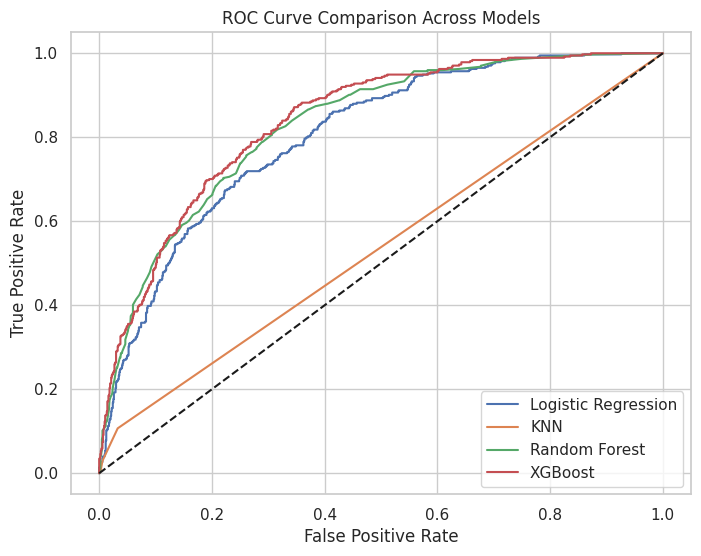

In [16]:
plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr_probs,
    "KNN": knn_probs,
    "Random Forest": rf_probs,
    "XGBoost": xgb_probs
}

for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison Across Models")
plt.legend()
plt.show()

In [17]:
print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



## XGBoost Insights

- XGBoost achieved the strongest ROC-AUC, indicating superior ability to distinguish between churn and non-churn customers.
- Gradient boosting captures complex, non-linear feature interactions that simpler models may miss.
- While XGBoost offers higher predictive performance, it comes at the cost of reduced interpretability compared to Logistic Regression.
- Model selection should balance predictive power with business needs such as explainability and deployment complexity.

Evaluated Logistic Regression, KNN, Random Forest, and XGBoost models using precision, recall, and ROC-AUC to identify optimal model performance under varying business constraints.